In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.tree import plot_tree, DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from collections import Counter
from imblearn.over_sampling import RandomOverSampler

In [5]:
col_names = ['date', 'precipitation',	'temp_max',	'temp_min',	'wind', 'weather'] 

df = pd.read_csv('../../seattle-weather(in).csv', names=col_names, header=None, skiprows=1)
df = df.drop('date', axis=1)

df_num = df.copy(deep=True)
df_num['weather'] = df_num['weather'].map({'drizzle': 0, 'rain': 1, 'sun': 2, 'snow': 3})

display(df.head())
display(df_num.head())

,precipitation,temp_max,temp_min,wind,weather
0,0.0,12.8,5.0,4.7,drizzle
1,10.9,10.6,2.8,4.5,rain
2,0.8,11.7,7.2,2.3,rain
3,20.3,12.2,5.6,4.7,rain
4,1.3,8.9,2.8,6.1,rain


,precipitation,temp_max,temp_min,wind,weather
0,0.0,12.8,5.0,4.7,0.0
1,10.9,10.6,2.8,4.5,1.0
2,0.8,11.7,7.2,2.3,1.0
3,20.3,12.2,5.6,4.7,1.0
4,1.3,8.9,2.8,6.1,1.0


weather
rain       641
sun        640
fog        101
drizzle     53
snow        26
Name: count, dtype: int64 weather
rain       0.438741
sun        0.438056
fog        0.069131
drizzle    0.036277
snow       0.017796
Name: proportion, dtype: float64


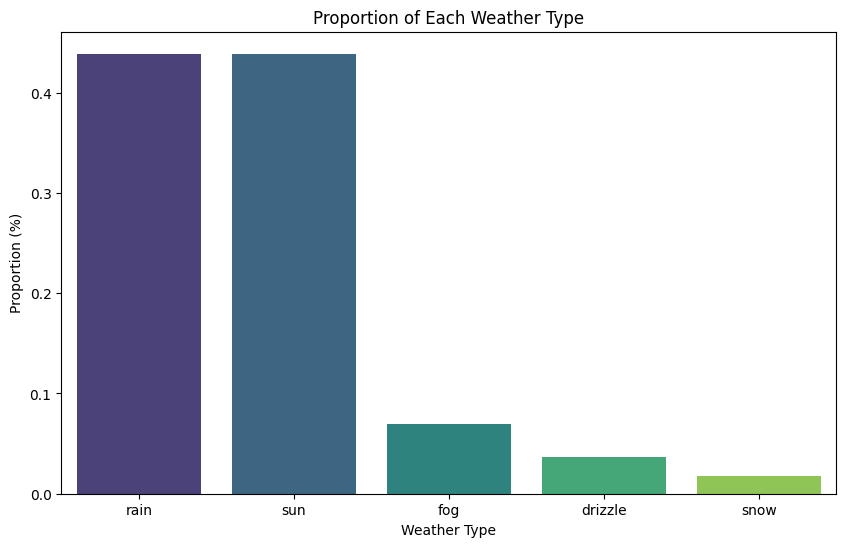

In [6]:
total = df['weather'].value_counts()
porcentajes = df['weather'].value_counts(normalize=True)

print(total, porcentajes)

plt.figure(figsize=(10, 6))
sns.barplot(x=porcentajes.index, y=porcentajes.values, hue=porcentajes.index, palette='viridis')
plt.title('Proportion of Each Weather Type')
plt.xlabel('Weather Type')
plt.ylabel('Proportion (%)')
plt.show()

Counter({'rain': 641, 'sun': 640, 'fog': 101, 'drizzle': 53, 'snow': 26})
Counter({'rain': 449, 'sun': 449, 'fog': 449, 'drizzle': 449, 'snow': 449})


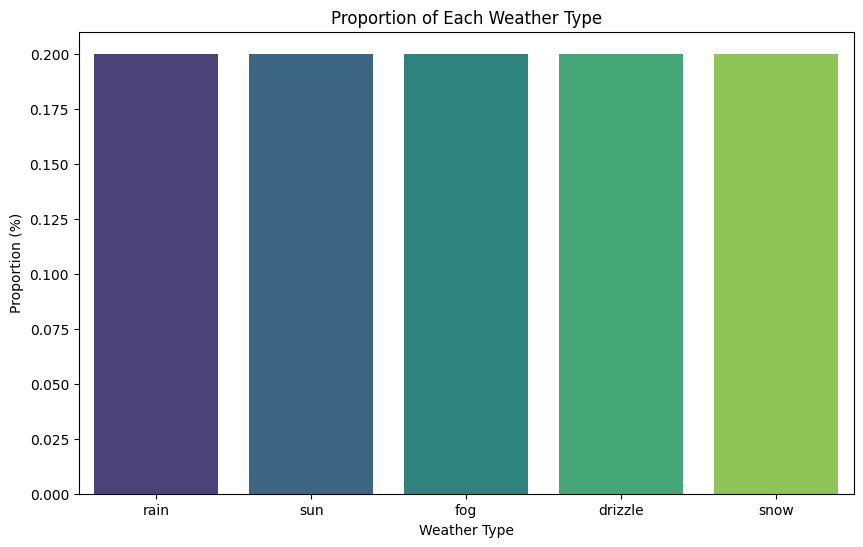

In [7]:
X = df.drop('weather', axis=1)
y = df['weather']

print(Counter(y))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ros = RandomOverSampler(random_state=42)

X_train_balanced, y_train_balanced = ros.fit_resample(X_train, y_train)

print(Counter(y_train_balanced))

porcentajes_balanced = y_train_balanced.value_counts(normalize=True)

plt.figure(figsize=(10, 6))
sns.barplot(x=porcentajes_balanced.index, y=porcentajes_balanced.values, hue=porcentajes_balanced.index, palette='viridis')
plt.title('Proportion of Each Weather Type')
plt.xlabel('Weather Type')
plt.ylabel('Proportion (%)')
plt.show()

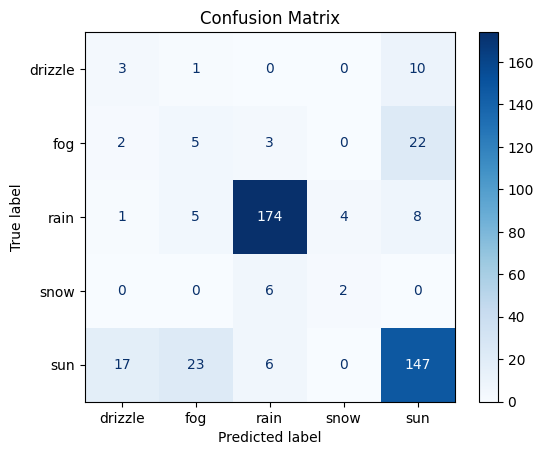

Classification Report:
                precision    recall  f1-score   support

     drizzle       0.13      0.21      0.16        14
         fog       0.15      0.16      0.15        32
        rain       0.92      0.91      0.91       192
        snow       0.33      0.25      0.29         8
         sun       0.79      0.76      0.77       193

    accuracy                           0.75       439
   macro avg       0.46      0.46      0.46       439
weighted avg       0.77      0.75      0.76       439



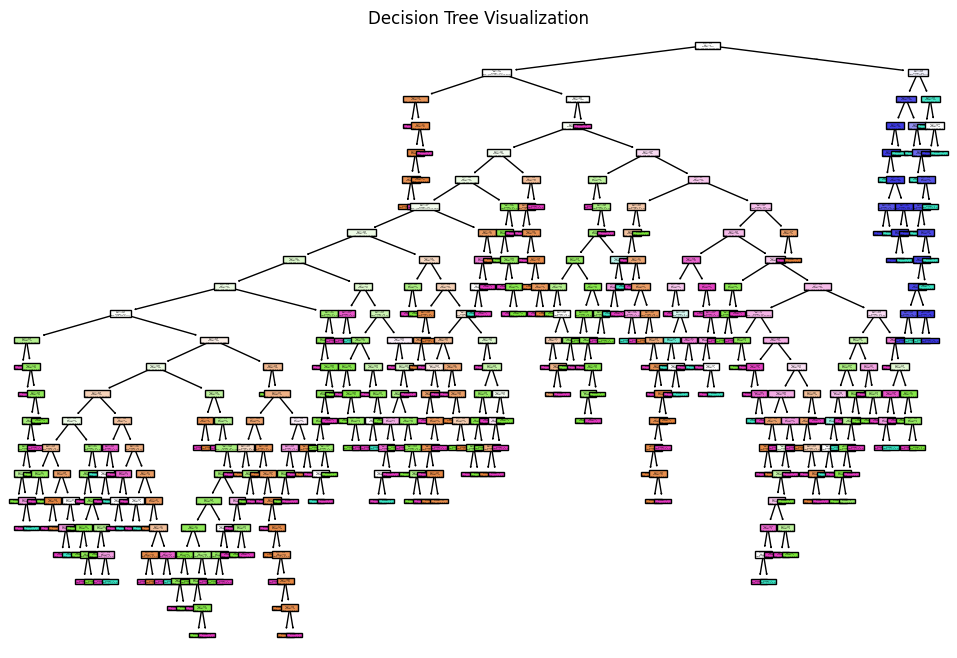

In [8]:
clf = DecisionTreeClassifier()
clf.fit(X_train_balanced, y_train_balanced)

y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


report = classification_report(y_test, y_pred, labels=clf.classes_)
print('Classification Report:\n ', report)

plt.figure(figsize=(12, 8))
plot_tree(clf, filled=True)
plt.title('Decision Tree Visualization')
plt.show()

In [11]:
param_grid = {
    'max_depth' : [2, 3, 4, 5, None],
    'min_samples_split' : [2, 4, 6, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2'],
    'max_leaf_nodes': [None, 5, 10, 20]
}

grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=1, verbose=1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
Best Hyperparameters: {'max_depth': 3, 'max_features': 'sqrt', 'max_leaf_nodes': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}


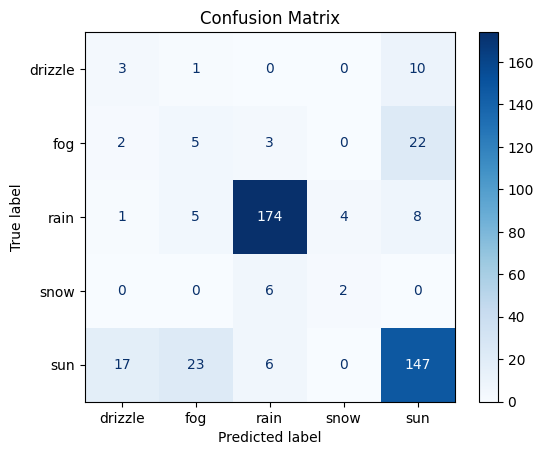

Classification Report:
                precision    recall  f1-score   support

     drizzle       0.13      0.21      0.16        14
         fog       0.15      0.16      0.15        32
        rain       0.92      0.91      0.91       192
        snow       0.33      0.25      0.29         8
         sun       0.79      0.76      0.77       193

    accuracy                           0.75       439
   macro avg       0.46      0.46      0.46       439
weighted avg       0.77      0.75      0.76       439



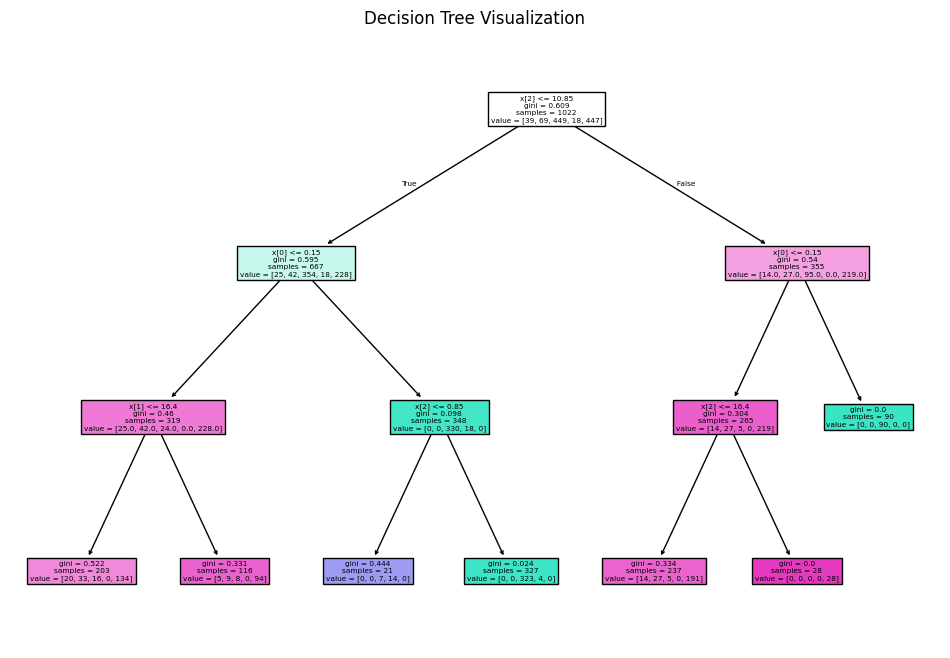

In [12]:
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


report = classification_report(y_test, y_pred, labels=best_model.classes_)
print('Classification Report:\n ', report)

plt.figure(figsize=(12, 8))
plot_tree(best_model, filled=True)
plt.title('Decision Tree Visualization')
plt.show()